# Import Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Import Dataset

In [2]:
df=pd.read_csv('../input/titanic/train.csv')

# Data overview

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# EDA

In [5]:
df['Survived'].value_counts()

0    549
1    342
Name: Survived, dtype: int64

<AxesSubplot:xlabel='Survived', ylabel='count'>

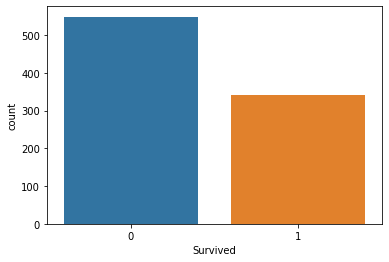

In [6]:
sns.countplot(data=df,x='Survived')

# Drop PassengerId & Name

In [7]:
df.drop('PassengerId', axis=1 , inplace=True)

In [8]:
df.drop('Name' , axis=1 , inplace=True)

In [9]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,female,35.0,1,0,113803,53.1000,C123,S
4,0,3,male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
df.corr()['Survived'].sort_values()

Pclass     -0.338481
Age        -0.077221
SibSp      -0.035322
Parch       0.081629
Fare        0.257307
Survived    1.000000
Name: Survived, dtype: float64

# Scatter Plot(fare & survived)

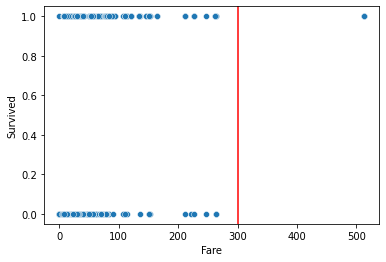

In [11]:
sns.scatterplot(data=df , x='Fare', y='Survived')
plt.axvline(x=300 , color='r')

# Specify the Outliers Row

In [12]:
df[(df['Fare']>300)&(df['Survived']>0.9)][['Fare','Survived']]

,Fare,Survived
258,512.3292,1
679,512.3292,1
737,512.3292,1


In [13]:
df[(df['Fare']>300)&(df['Survived']>0.1)][['Fare','Survived']]

,Fare,Survived
258,512.3292,1
679,512.3292,1
737,512.3292,1


# Drop the Outliers Row

In [14]:
index_drop=df[(df['Fare']>300)&(df['Survived']>0.1)].index

In [15]:
index_drop

Int64Index([258, 679, 737], dtype='int64')

In [16]:
df=df.drop(index_drop , axis=0)

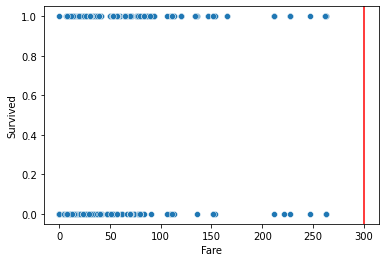

In [17]:
sns.scatterplot(data=df , x='Fare', y='Survived')
plt.axvline(x=300 , color='r')

<AxesSubplot:xlabel='Survived', ylabel='Fare'>

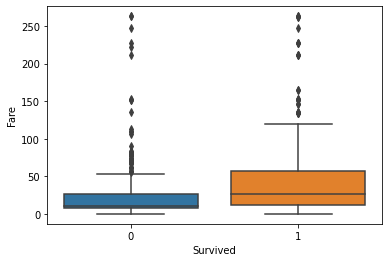

In [18]:
sns.boxplot(data=df,x='Survived',y='Fare')

# Missing Data Detect

In [19]:
((df.isnull().sum())/len(df))*100

Survived     0.000000
Pclass       0.000000
Sex          0.000000
Age         19.932432
SibSp        0.000000
Parch        0.000000
Ticket       0.000000
Fare         0.000000
Cabin       77.252252
Embarked     0.225225
dtype: float64

In [20]:
def missing_percent(df):
    nan_percent=((df.isnull().sum())/len(df))*100
    nan_percent=nan_percent[nan_percent>0].sort_values()
    return nan_percent

In [21]:
nan_percent=missing_percent(df)

In [22]:
nan_percent

Embarked     0.225225
Age         19.932432
Cabin       77.252252
dtype: float64

(array([0, 1, 2]),
 [Text(0, 0, 'Embarked'), Text(1, 0, 'Age'), Text(2, 0, 'Cabin')])

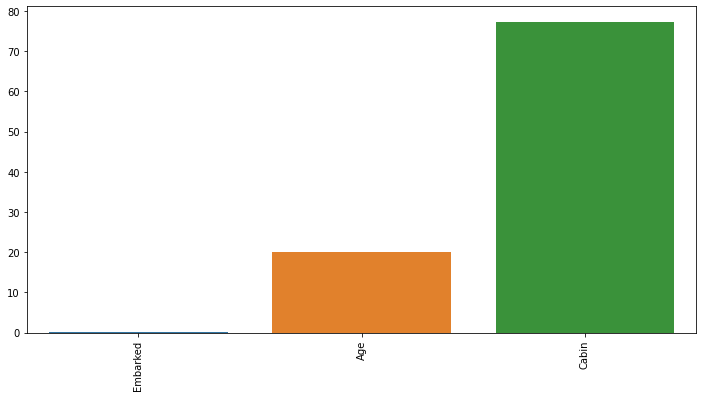

In [23]:
plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index , y=nan_percent)
plt.xticks(rotation=90)

In [24]:
df[df['Embarked'].isnull()]

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,1,1,female,38.0,0,0,113572,80.0,B28,NaN
829,1,1,female,62.0,0,0,113572,80.0,B28,NaN


In [25]:
df= df.dropna(axis=0, subset=['Embarked'])

In [26]:
df.drop("Cabin", axis = 1, inplace = True)

In [27]:
df["Age"].fillna(df["Age"].mean(), inplace = True)

In [28]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

# Features & Label

In [29]:
df['Sex']=df['Sex'].replace({'male':0,'female':1})
df.drop([ 'Ticket', 'Fare','Embarked'], axis = 1, inplace = True)
X=df.drop('Survived' , axis=1)
y=df['Survived']

# Train & Test

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train , X_test ,y_train, y_test=train_test_split(X, y , test_size=0.1, random_state=101)

# Scalling the Features

In [32]:
from sklearn.preprocessing import StandardScaler

In [33]:
scaler=StandardScaler()

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 886 entries, 0 to 890
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  886 non-null    int64  
 1   Pclass    886 non-null    int64  
 2   Sex       886 non-null    int64  
 3   Age       886 non-null    float64
 4   SibSp     886 non-null    int64  
 5   Parch     886 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 48.5 KB


In [35]:
scaler.fit(X_train)

StandardScaler()

In [36]:
scaled_X_train=scaler.transform(X_train)
scaled_X_test=scaler.transform(X_test)

# Train the model

In [37]:
from sklearn.linear_model import LogisticRegression

In [38]:
log_model=LogisticRegression()

In [39]:
log_model.fit(scaled_X_train,y_train)

LogisticRegression()

In [40]:
log_model.coef_

array([[-0.93510967,  1.33602852, -0.45714017, -0.42488102, -0.05495669]])

# Predicting Test Data

In [41]:
y_pred=log_model.predict(scaled_X_test)

# Evaluating the Model

In [42]:
from sklearn.metrics import accuracy_score,confusion_matrix , classification_report

In [43]:
accuracy_score(y_test,y_pred)

0.7528089887640449

In [44]:
confusion_matrix(y_test,y_pred)

array([[48,  9],
       [13, 19]])

In [45]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.84      0.81        57
           1       0.68      0.59      0.63        32

    accuracy                           0.75        89
   macro avg       0.73      0.72      0.72        89
weighted avg       0.75      0.75      0.75        89



In [46]:
from sklearn.metrics import precision_recall_curve,plot_precision_recall_curve,plot_roc_curve

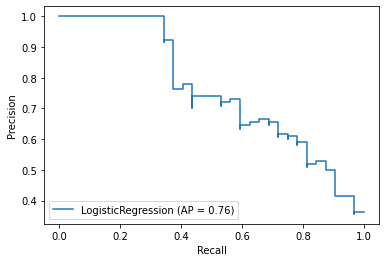

In [47]:
plot_precision_recall_curve(log_model , scaled_X_test , y_test)

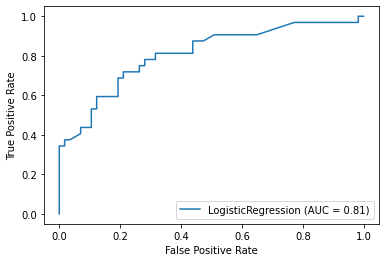

In [48]:
plot_roc_curve(log_model,scaled_X_test, y_test)